# WATL viral AMGs

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

AMG_TSV = "/Users/skoog/Desktop/amg_summary.tsv"
FIG_DIR = Path(AMG_TSV).parent / "amg_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MAX_AUX_SCORE      = 2
REQUIRE_M_FLAG     = True
HARD_EXCLUDE_FLAGS = set()
REMOVE_FS          = False
REMOVE_TRANSPOSONS = False
SCORE_SWEEP        = [2, 1]

mpl.rcParams["svg.fonttype"] = "none"    
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["font.family"]  = "Arial"
plt.rcParams.update({"figure.dpi":130, "savefig.dpi":300, "savefig.bbox":"tight",
                     "font.size":10, "axes.spines.top":False, "axes.spines.right":False})

def save(fig, stem):
    extra = [a for ax in fig.axes for a in [ax.get_legend()] if a]
    for ext, kw in [("svg", {}), ("png", {"dpi": 300})]:
        fig.savefig(FIG_DIR / f"{stem}.{ext}", bbox_inches="tight",
                    bbox_extra_artists=extra, **kw)

amg = pd.read_csv(AMG_TSV, sep="\t", dtype=str)
amg["auxiliary_score"] = pd.to_numeric(amg["auxiliary_score"], errors="coerce")
amg["amg_flags"] = amg["amg_flags"].fillna("")
for c in ["gene_description","module","header","sheet","subheader"]:
    amg[c] = amg[c].fillna("") if c in amg.columns else ""

print(f"{len(amg):,} rows | {amg['gene'].nunique():,} genes")

1,322 rows | 889 genes


In [2]:
#filter
def flag_test(flags):
    return {"has_M":   ("M" in flags) or not REQUIRE_M_FLAG,
            "no_hard": len(set(flags) & HARD_EXCLUDE_FLAGS) == 0,
            "no_F":    ("F" not in flags) or not REMOVE_FS,
            "no_T":    ("T" not in flags) or not REMOVE_TRANSPOSONS}

f = amg["amg_flags"].apply(flag_test).apply(pd.Series)
amg["pass_score"]  = amg["auxiliary_score"] <= MAX_AUX_SCORE
amg["pass_cutoff"] = amg["pass_score"] & f["has_M"] & f["no_hard"] & f["no_F"] & f["no_T"]

strict_mask = (amg["pass_score"] & f["has_M"]
               & ~amg["amg_flags"].str.contains("F") & ~amg["amg_flags"].str.contains("T"))

steps = {"all rows": pd.Series(True, index=amg.index),
         f"score \u2264 {MAX_AUX_SCORE}": amg["pass_score"],
         "+ (M) flag": amg["pass_score"] & f["has_M"],
         "+ no F/T": strict_mask}
waterfall = pd.DataFrame({"genes": {k: amg.loc[v,"gene"].nunique() for k,v in steps.items()},
                          "rows":  {k: int(v.sum()) for k,v in steps.items()}})
print(waterfall)

survivors_genes = amg[amg["pass_cutoff"]].drop_duplicates("gene").copy()
strict_genes    = amg[strict_mask].drop_duplicates("gene").copy()
print(f"\nprimary  {len(survivors_genes)} genes / {survivors_genes['scaffold'].nunique()} contigs")
print(f"no F/T   {len(strict_genes)} genes / {strict_genes['scaffold'].nunique()} contigs")

            genes  rows
all rows      889  1322
score ≤ 2     382   502
+ (M) flag    382   502
+ no F/T      122   170

primary  382 genes / 274 contigs
no F/T   122 genes / 59 contigs


In [3]:
#functions
SYMBOL_KEYWORDS = {"phoh","phoa","sped","quec","quef","trk","kdp","kup","pstb",
                   "psba","psbd","cpet","cpes","cp12","gale","mana","nrda","nrdb","cobs","cobt"}

def kw_match(text, keyword):
    if keyword in SYMBOL_KEYWORDS:
        return re.search(r"(?<![a-z])"+re.escape(keyword)+r"(?![a-z])", text) is not None
    return keyword in text

USE_DESCRIPTION_ONLY = True

FUNCTION_RULES = [
    ("Photosynthesis / phycobilin", ["psba","psbd","photosystem","phycoerythrin","phycobilin",
                                     "bilin reductase","cpet","cpes","cp12","heme oxygenase","calvin"]),
    ("DNA methylation / RM",        ["cytosine-5-","cytosine-specific","adenine-specific",
                                     "dna methyltransferase","dna (cytosine","restriction endonuclease",
                                     "modification methylase"]),
    ("2OG-Fe(II) oxygenase",        ["2og-fe","oxoglutarate/iron-dependent","fe(ii) oxygenase"]),
    ("Sulfotransferase",            ["sulfotransferase"]),
    ("Osmolyte / stress",           ["ectoine","betaine","trehalose","choline","glucosylglycerol",
                                     "compatible solute","osmoprotect"]),
    ("Polyamine",                   ["sped","s-adenosylmethionine decarboxylase","spermidine",
                                     "polyamine","putrescine"]),
    ("Phosphate / nutrient",        ["phoh","phoa","phosphate starvation","phosphate transport",
                                     "alkaline phosphatase","pstb","phosphonate"]),
    ("Nucleotide metabolism",       ["ribonucleoside-diphosphate reductase","nrda","nrdb",
                                     "ribonucleotide reductase","dutp","dctp","dtmp","dcmp",
                                     "thymidylate","cytidylyltransferase","deoxyrib","pyrimidine",
                                     "purine","guanylate kinase","adenylosuccinate","carbamoyltransferase"]),
    ("Cofactor / vitamin / tRNA",   ["cobalamin","corrin","cobaltochelatase","cobs","cobt","precorrin",
                                     "folate","biotin","riboflavin","porphyrin","molybdopterin",
                                     "pantothenate","thiamine","pterin","cyclohydrolase","queuosine",
                                     "quec","quef","formyl transferase","pyridoxal","phosphopantetheine",
                                     "nicotinate phosphoribosyltransferase","naprtase"]),
    ("Amino-acid metabolism",       ["histidine biosynthesis","phosphoribosyl-atp","chorismate mutase",
                                     "aminotransferase","hydroxymethyltransferase","methionine",
                                     "arginine","glutamate","cysteine","amino acid","aminopeptidase"]),
    ("Glycan binding / adhesion",   ["concanavalin a-like lectin","laminin_g","lectin",
                                     "carbohydrate-binding module","ricin"]),
    ("Carbohydrate / CAZy",         ["rmld","nad dependent epimerase","dtdp","hydroxysteroid",
                                     "glycosyl transferase","glycosyltransferase","gale","udp-glucose",
                                     "gdp-mannose","mana","acetylglucosaminidase","arabinofuranosidase",
                                     "arabinase","hexapeptide","epimerase","dehydratase","galactose",
                                     "sugar","polysaccharide","pectin","glucosidase","phosphogluconate",
                                     "mannosyl","pentose","glycolysis"]),
    ("Lipid metabolism",            ["phospholipase","patatin","ketoacyl","fatty acid","acyl carrier",
                                     "desaturase","isoprenoid"]),
    ("Energy & electron transp",    ["cytochrome","ubiquinol","ferredoxin","rubredoxin",
                                     "nad(p)h dehydrogenase","nad(p) transhydrogenase",
                                     "electron transfer","hydrogenase","terminal oxidase"]),
    ("Sulfur / nitrogen",           ["sulfate","sulfite","sulfur","taurine","nitrogen","nitrate",
                                     "nitrite","nitrogenase","urea"]),
    ("Peptidase / protease",        ["peptidase","protease"]),
]

def classify(row):
    t = (str(row["gene_description"]).lower() if USE_DESCRIPTION_ONLY
         else f"{row['gene_description']} {row['module']} {row['header']} {row['sheet']}".lower())
    for cat, kws in FUNCTION_RULES:
        if any(kw_match(t, k) for k in kws):
            return cat
    return "Other / unclassified"

for df in (survivors_genes, strict_genes):
    df["function"] = df.apply(classify, axis=1)

func_counts = survivors_genes["function"].value_counts()
print(func_counts.to_string())
print(f"total {func_counts.sum()}")

oth = survivors_genes[survivors_genes.function == "Other / unclassified"]
print(f"\nunclassified ({len(oth)}):")
print(oth.gene_description.value_counts().to_string() if len(oth) else "  none")

function
Carbohydrate / CAZy            85
Nucleotide metabolism          67
Glycan binding / adhesion      51
2OG-Fe(II) oxygenase           44
Cofactor / vitamin / tRNA      37
Phosphate / nutrient           24
Sulfotransferase               23
DNA methylation / RM           18
Amino-acid metabolism          11
Photosynthesis / phycobilin     7
Other / unclassified            4
Lipid metabolism                4
Polyamine                       4
Energy & electron transp        3
total 382

unclassified (4):
gene_description
Self-processing occurs at the Ser846|+|Ala bond.    3
small subunit ribosomal protein S21                 1


In [4]:
PALETTE = {
    "Carbohydrate / CAZy":          "#3d6fb4",
    "Glycan binding / adhesion":    "#4a90c4",
    "Nucleotide metabolism":        "#2a7f62",
    "2OG-Fe(II) oxygenase":         "#8c6d4f",
    "Cofactor / vitamin / tRNA":    "#c9a03a",
    "Phosphate / nutrient":         "#5a9e5a",
    "Sulfotransferase":             "#7a6aa8",
    "DNA methylation / RM":         "#b5495b",
    "Lipid metabolism":             "#a05a7a",
    "Amino-acid metabolism":        "#c8622d",
    "Photosynthesis / phycobilin":  "#2e9e6b",
    "Polyamine":                    "#d18f3f",
    "Energy & electron transp":     "#1b7f9e",
    "Osmolyte / stress":            "#d64545",
    "Sulfur / nitrogen":            "#6a8caf",
    "Peptidase / protease":         "#888888",
    "Other / unclassified":         "#bbbbbb",
}


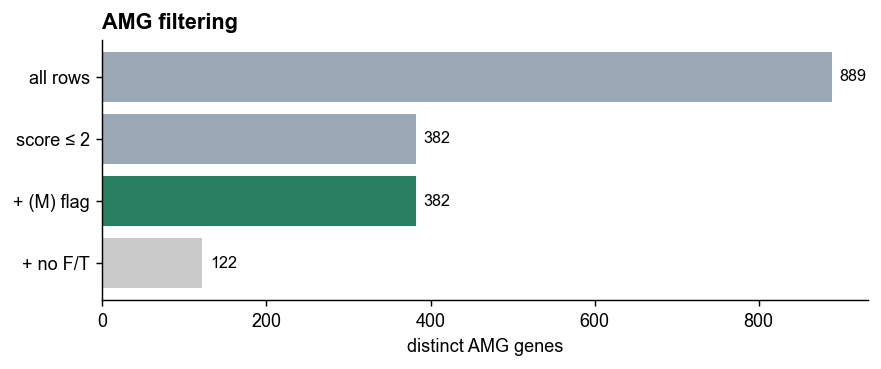

In [22]:
#fgiure
fig, ax = plt.subplots(figsize=(7.6, 2.6))
vals = waterfall["genes"].values
bars = ax.barh(range(len(vals)), vals, color=["#9aa7b5","#9aa7b5","#2a7f62","#c9c9c9"])
ax.set_yticks(range(len(vals))); ax.set_yticklabels(waterfall.index)
ax.invert_yaxis(); ax.set_xlabel("distinct AMG genes")
ax.set_title("AMG filtering", loc="left", fontweight="bold")
for b, v in zip(bars, vals):
    ax.text(v + max(vals)*0.01, b.get_y()+b.get_height()/2, str(v), va="center", fontsize=9)
save(fig, "figA_cutoff_waterfall"); plt.show()

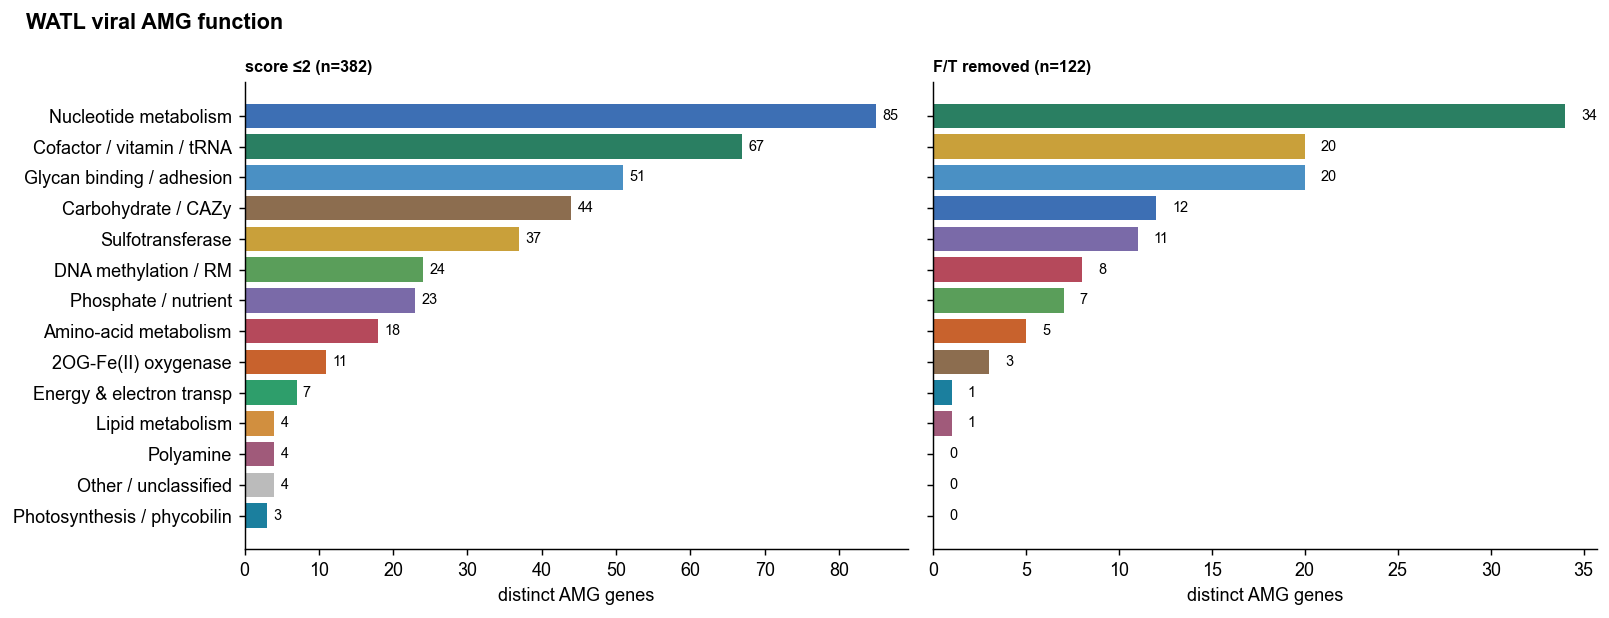

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)
for ax, (d, lab) in zip(axes, [(survivors_genes, f"score \u22642 (n={len(survivors_genes)})"),
                               (strict_genes,    f"F/T removed (n={len(strict_genes)})")]):
    fc = d["function"].value_counts().reindex(func_counts.index).fillna(0).sort_values()
    ax.barh(fc.index, fc.values, color=[PALETTE.get(c,"#999") for c in fc.index])
    for i, v in enumerate(fc.values):
        ax.text(v + max(func_counts.values)*0.01, i, str(int(v)), va="center", fontsize=8)
    ax.set_xlabel("distinct AMG genes")
    ax.set_title(lab, loc="left", fontsize=9, fontweight="bold")
fig.suptitle("WATL viral AMG function", x=0.02, ha="left", fontweight="bold")
fig.tight_layout(); save(fig, "figB_function_composition"); plt.show()

In [6]:
def inventory(df):
    d = df.copy()
    d["gene_product"] = (d["gene_description"].str.replace(r"\s*\[.*$", "", regex=True)
                          .str.strip().replace("", "unannotated"))
    return (d.groupby(["function","gene_product"])
              .agg(n_genes=("gene","size"), n_contigs=("scaffold","nunique"))
              .reset_index().sort_values(["function","n_genes"], ascending=[True,False]))

inv = inventory(survivors_genes)
inv.to_csv(FIG_DIR/"amg_gene_inventory_primary.tsv", sep="\t", index=False)
inventory(strict_genes).to_csv(FIG_DIR/"amg_gene_inventory_strict.tsv", sep="\t", index=False)

for cat in func_counts.index:
    d = inv[inv.function == cat]
    if not len(d): continue
    print(f"\n{cat}  ({d.n_genes.sum()})")
    for _, r in d.iterrows():
        print(f"   {r.n_genes:3d}  {r['gene_product'][:66]}")

print("\ntop 20:")
print(inv.nlargest(20, "n_genes")[["gene_product","function","n_genes","n_contigs"]]
        .to_string(index=False, max_colwidth=52))


Carbohydrate / CAZy  (85)
    46  Glycosyl transferases group 1
    11  3-beta hydroxysteroid dehydrogenase/isomerase family
     6  Mannosyl-glycoprotein endo-beta-N-acetylglucosaminidase
     6  NAD dependent epimerase/dehydratase family
     5  Bacterial transferase hexapeptide (six repeats)
     4  Glycosyltransferase sugar-binding region containing DXD motif
     2  Glycosyltransferase family 17
     1  Alpha-L-arabinofuranosidase B, catalytic
     1  GALE; UDP-Glc -> UDP-Gal
     1  NAD binding domain of 6-phosphogluconate dehydrogenase
     1  UDP-glucose/GDP-mannose dehydrogenase family, NAD binding domain
     1  manA; mannose-6-phosphate isomerase

Nucleotide metabolism  (67)
    17  ribonucleoside-diphosphate reductase
    14  nrdA/nrdB; ribonucleotide reductase (RNR)
    11  Cytidylyltransferase
     8  dCTP deaminase
     5  dUTP pyrophosphatase
     4  Carbamoyltransferase
     3  dTMP kinase
     3  thymidylate synthase
     1  Guanylate kinase
     1  adenylosuccinate 

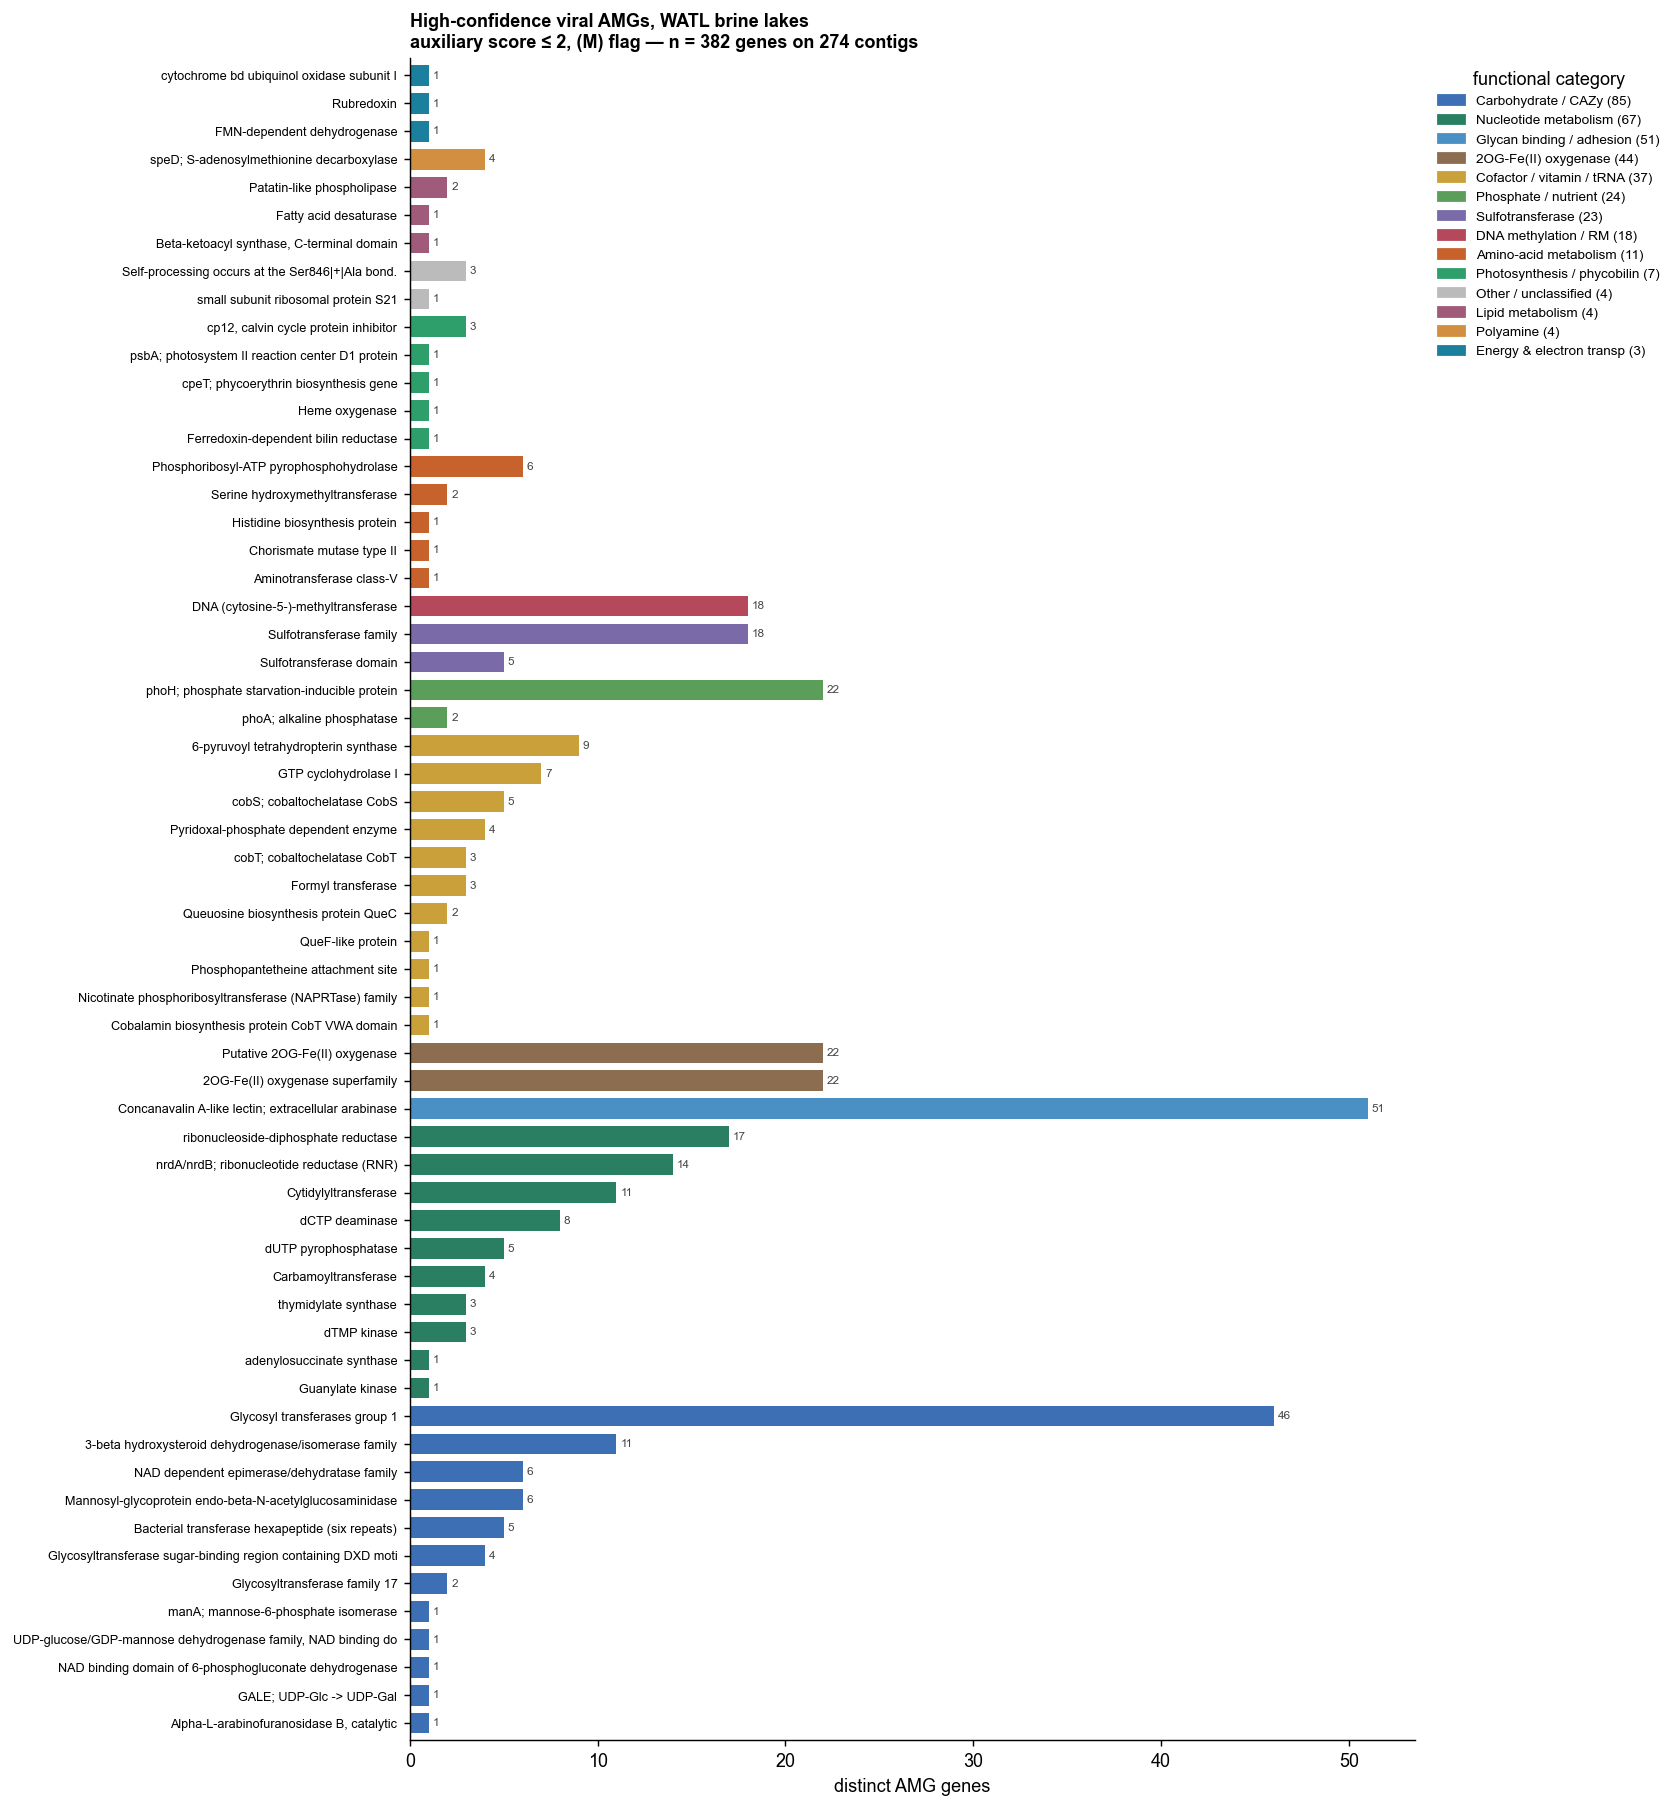

In [7]:
MIN_COPIES = 1
TRUNCATE   = 60

d = inv[inv.n_genes >= MIN_COPIES].copy()
order = [c for c in func_counts.index if c in set(d.function)]
d["__c"] = d.function.map({c:i for i,c in enumerate(order)})
d = d.sort_values(["__c","n_genes"], ascending=[True,True])

fig, ax = plt.subplots(figsize=(13, max(5, 0.28*len(d))))
y = np.arange(len(d))
ax.barh(y, d.n_genes, color=[PALETTE.get(f,"#999") for f in d.function], height=0.74)
ax.set_yticks(y); ax.set_yticklabels(d["gene_product"].str.slice(0,TRUNCATE), fontsize=7)
for i, n in enumerate(d.n_genes):
    ax.text(n+0.2, i, str(n), va="center", fontsize=6.5, color="#444")
ax.set_xlabel("distinct AMG genes")
ax.set_title("High-confidence viral AMGs, WATL brine lakes\n"
             f"auxiliary score \u2264 {MAX_AUX_SCORE}, (M) flag \u2014 "
             f"n = {len(survivors_genes)} genes on {survivors_genes['scaffold'].nunique()} contigs",
             loc="left", fontweight="bold", fontsize=10)
handles = [plt.Rectangle((0,0),1,1,color=PALETTE.get(c,"#999")) for c in order]
ax.legend(handles, [f"{c} ({int(func_counts[c])})" for c in order],
          loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False,
          fontsize=7.5, title="functional category")
ax.margins(y=0.004)
fig.subplots_adjust(right=0.72)
save(fig, "figE_amg_inventory"); plt.show()

In [26]:
#stress genes
STRESS_RULES = {
  "Osmotic / salinity": ["ectoine","hydroxyectoine","betaine","glycine betaine","choline","trehalose",
                         "glucosylglycerol","compatible solute","osmoprotect","mechanosensitive",
                         "proline/glycine","taurine","s-adenosylmethionine decarboxylase",
                         "spermidine","polyamine"],
  "Acid / pH homeostasis": ["glutamate decarboxylase","arginine decarboxylase","lysine decarboxylase",
                         "ornithine decarboxylase","arginine deiminase","urease","na+/h+",
                         "sodium/proton","antiport","carbonic anhydrase","proton-translocating",
                         "f-type atpase","v-type atpase","alkaliphil","alkaline stress"],
  "Oxidative / general": ["glutathione","peroxidase","catalase","superoxide","thioredoxin",
                         "glutaredoxin","universal stress"],
  "Phosphate starvation": ["phoh","phoa","phosphate starvation","alkaline phosphatase"],
}

def stress_class(row):
    t = str(row["gene_description"]).lower()
    for cls, kws in STRESS_RULES.items():
        if any(kw_match(t, k) for k in kws): return cls
    return ""


POLYAMINE_RX = r"(?<![a-z])sped(?![a-z])|s-adenosylmethionine decarboxylase|spermidine|polyamine"
OSMOLYTE_RX  = r"ectoine|betaine|trehalose|glucosylglycerol|compatible solute|osmoprotect"
IONTRANS_RX  = (r"(?<![a-z])trk(?![a-z])|(?<![a-z])kdp(?![a-z])|(?<![a-z])kef(?![a-z])|"
                r"(?<![a-z])nha(?![a-z])|na\+|sodium|potassium|mechanosensitive|cation|"
                r"chloride|aquaporin")

for df in (survivors_genes, strict_genes):
    df["stress_class"] = df.apply(stress_class, axis=1)

desc = survivors_genes["gene_description"].str.lower()
osm  = survivors_genes[survivors_genes.stress_class == "Osmotic / salinity"]
poly = osm[osm.gene_description.str.lower().str.contains(POLYAMINE_RX)]

print(f"n = {len(survivors_genes)}")
print(f"  osmotic-classed        {len(osm)}")
print(f"    polyamine (speD)     {len(poly)}")
print(f"    compatible solute    {len(osm) - len(poly)}")
print(f"  osmolyte regex         {int(desc.str.contains(OSMOLYTE_RX).sum())}")
print(f"  ion/osmolyte transport {int(desc.str.contains(IONTRANS_RX).sum())}")
if len(osm):
    print()
    print(osm[["gene_id","scaffold","auxiliary_score","amg_flags","gene_description"]]
            .to_string(index=False, max_colwidth=52))

n = 382
  osmotic-classed        4
    polyamine (speD)     4
    compatible solute    0
  osmolyte regex         0
  ion/osmolyte transport 0

gene_id                 scaffold  auxiliary_score amg_flags                         gene_description
PF02675 WATLvirus_00273463-cat_1                2       MKF speD; S-adenosylmethionine decarboxylase
PF02675 WATLvirus_00316014-cat_1                2       MKF speD; S-adenosylmethionine decarboxylase
PF02675 WATLvirus_00318998-cat_1                2       MKF speD; S-adenosylmethionine decarboxylase
PF02675 WATLvirus_00325951-cat_1                2       MKF speD; S-adenosylmethionine decarboxylase


In [27]:
def build_set(t, strict):
    m = (amg["auxiliary_score"] <= t) & amg["amg_flags"].str.contains("M")
    m &= ~amg["amg_flags"].apply(lambda fl: bool(set(fl) & HARD_EXCLUDE_FLAGS))
    if strict:
        m &= ~amg["amg_flags"].str.contains("F") & ~amg["amg_flags"].str.contains("T")
    g = amg[m].drop_duplicates("gene").copy()
    g["function"]     = g.apply(classify, axis=1)
    g["stress_class"] = g.apply(stress_class, axis=1)
    return g

def grid_row(t, strict):
    g = build_set(t, strict); d = g["gene_description"].str.lower()
    osm = g[g.stress_class == "Osmotic / salinity"]
    return {"aux_score": f"\u2264{t}", "F/T": "removed" if strict else "retained",
            "AMG_genes": g.gene.nunique(), "contigs": g.scaffold.nunique(),
            "phoH": int(d.str.contains(r"(?<![a-z])phoh(?![a-z])").sum()),
            "phoA": int(d.str.contains(r"(?<![a-z])phoa(?![a-z])").sum()),
            "osmotic_classed": len(osm),
            "polyamine": int(osm.gene_description.str.lower().str.contains(POLYAMINE_RX).sum()),
            "true_osmolyte": int(d.str.contains(OSMOLYTE_RX).sum()),
            "ion_transport": int(d.str.contains(IONTRANS_RX).sum())}

grid = pd.DataFrame([grid_row(t, st) for t in SCORE_SWEEP for st in (False, True)])
print(grid.to_string(index=False))
grid.to_csv(FIG_DIR/"amg_cutoff_grid.csv", index=False)

if grid.ion_transport.sum() == 0 and grid.true_osmolyte.sum() == 0:
    big = grid.loc[grid.AMG_genes.idxmax()]
    print(f"\nno ion-transport or compatible-solute AMG at any threshold tested "
          f"(largest set: {big.aux_score}, F/T {big['F/T']}, n={big.AMG_genes})")

aux_score      F/T  AMG_genes  contigs  phoH  phoA  osmotic_classed  polyamine  true_osmolyte  ion_transport
       ≤2 retained        382      274    22     2                4          4              0              0
       ≤2  removed        122       59     6     1                0          0              0              0
       ≤1 retained        112       69     5     1                0          0              0              0
       ≤1  removed         58       24     4     1                0          0              0              0

no ion-transport or compatible-solute AMG at any threshold tested (largest set: ≤2, F/T retained, n=382)


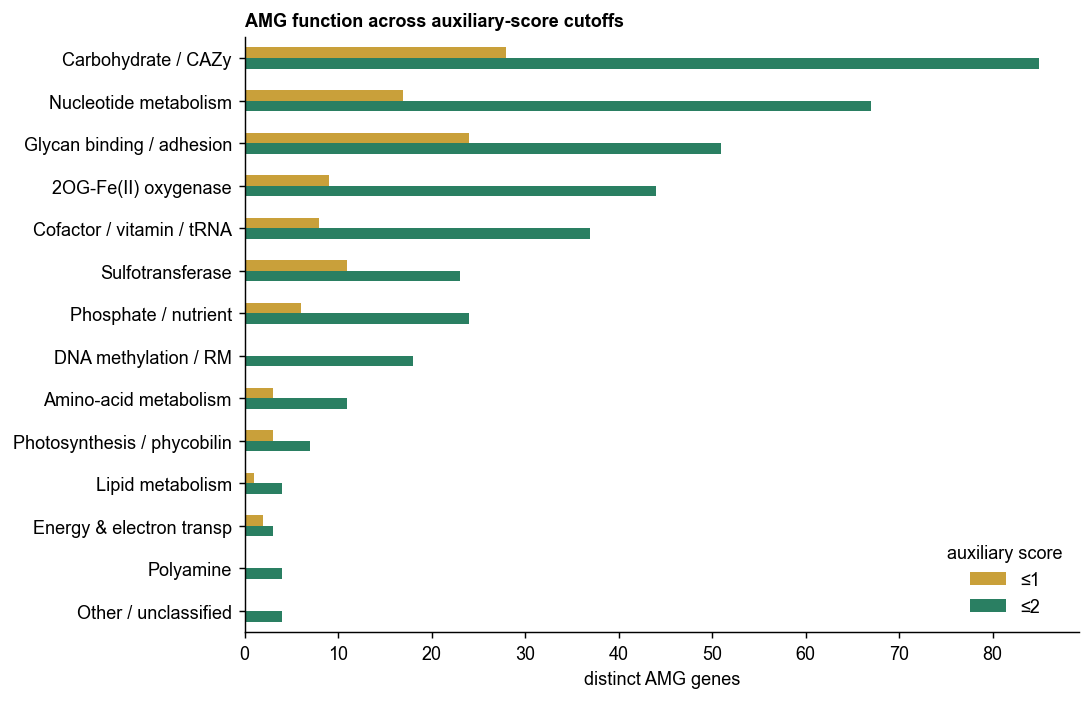

                             ≤2  ≤1
function                           
Other / unclassified          4   0
Polyamine                     4   0
Energy & electron transp      3   2
Lipid metabolism              4   1
Photosynthesis / phycobilin   7   3
Amino-acid metabolism        11   3
DNA methylation / RM         18   0
Phosphate / nutrient         24   6
Sulfotransferase             23  11
Cofactor / vitamin / tRNA    37   8
2OG-Fe(II) oxygenase         44   9
Glycan binding / adhesion    51  24
Nucleotide metabolism        67  17
Carbohydrate / CAZy          85  28


In [28]:
comp = {f"\u2264{t}": build_set(t, strict=False)["function"].value_counts() for t in SCORE_SWEEP}
comp_df = pd.DataFrame(comp).fillna(0).astype(int)
comp_df = comp_df.loc[comp_df.sum(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
comp_df.plot(kind="barh", ax=ax, color=["#2a7f62","#c9a03a","#6aa9c9"][:len(SCORE_SWEEP)])
ax.set_xlabel("distinct AMG genes"); ax.set_ylabel("")
ax.set_title("AMG function across auxiliary-score cutoffs", loc="left", fontweight="bold", fontsize=10)
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], title="auxiliary score", frameon=False)
fig.tight_layout(); save(fig, "figD_score_sensitivity"); plt.show()
print(comp_df.to_string())

112 genes / 69 contigs
function
Carbohydrate / CAZy            28
Glycan binding / adhesion      24
Nucleotide metabolism          17
Sulfotransferase               11
2OG-Fe(II) oxygenase            9
Cofactor / vitamin / tRNA       8
Phosphate / nutrient            6
Amino-acid metabolism           3
Photosynthesis / phycobilin     3
Energy & electron transp        2
Lipid metabolism                1


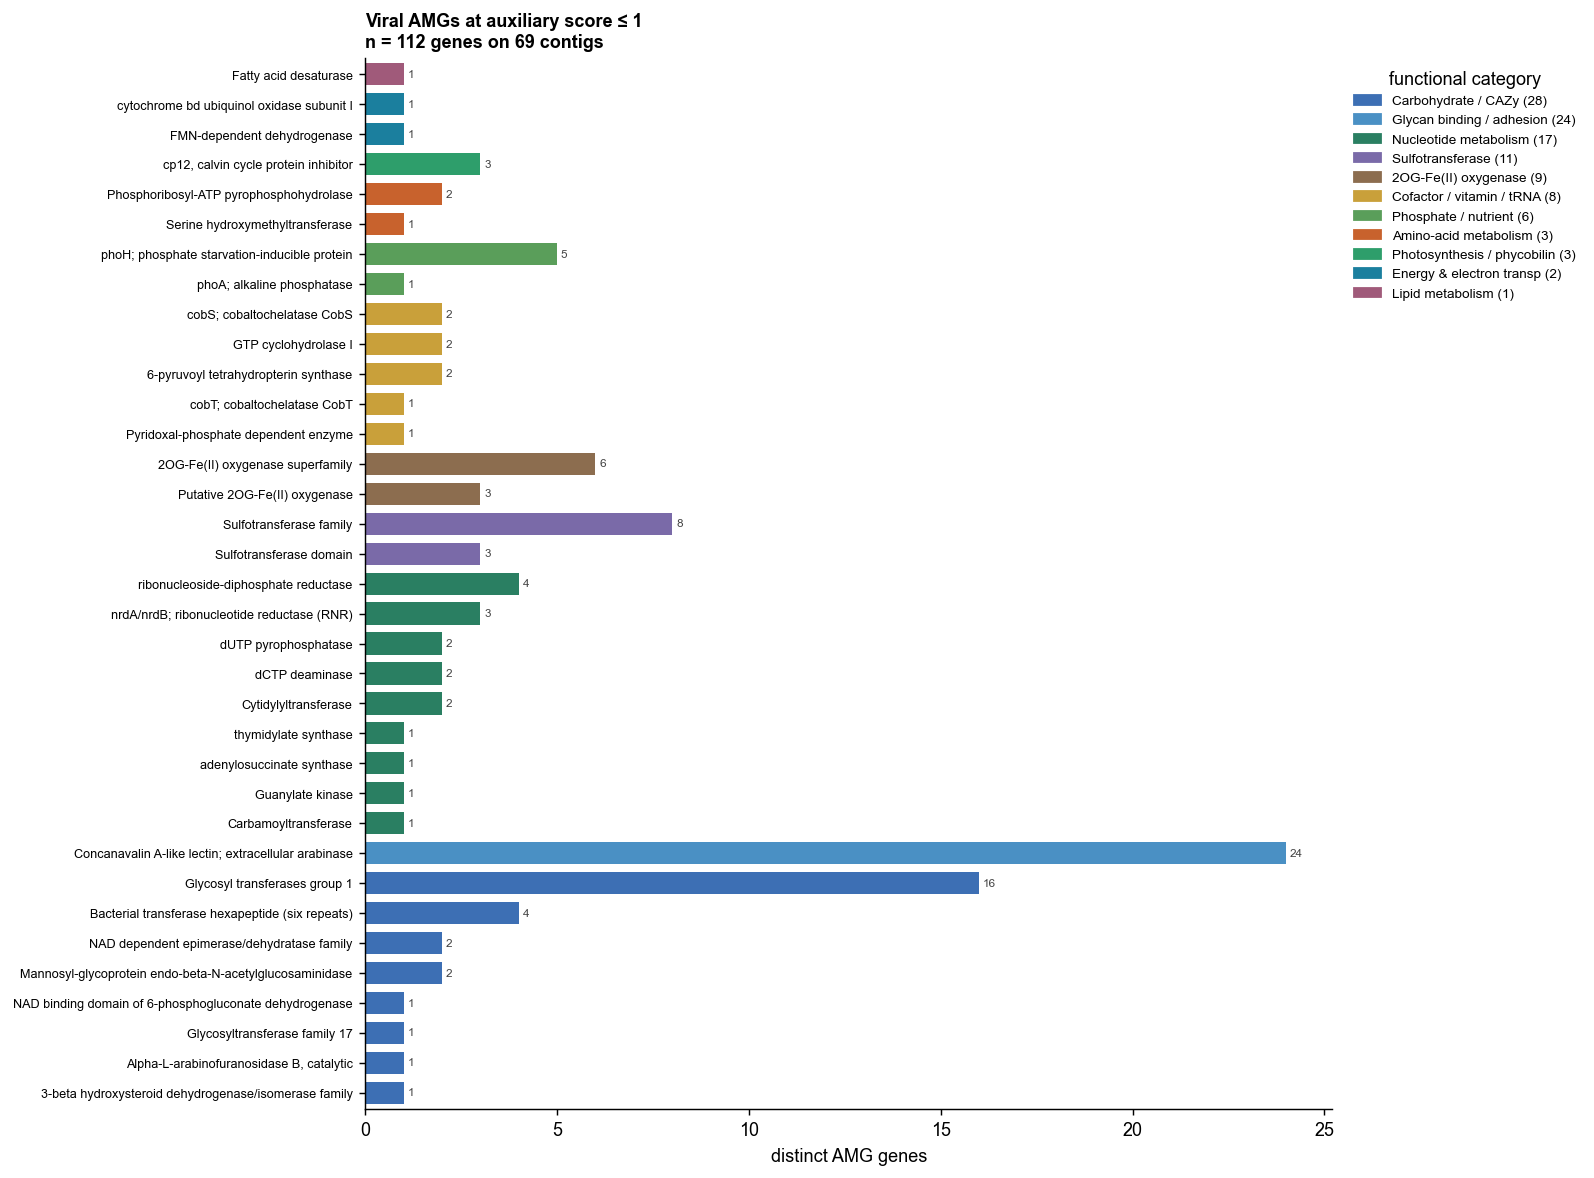

In [29]:
#cuttoff of 1
one  = build_set(1, strict=False)
inv1 = inventory(one)
fc1  = one["function"].value_counts()
inv1.to_csv(FIG_DIR/"amg_gene_inventory_score1.tsv", sep="\t", index=False)
print(f"{len(one)} genes / {one['scaffold'].nunique()} contigs")
print(fc1.to_string())

d = inv1.copy()
order = [c for c in fc1.index if c in set(d.function)]
d["__c"] = d.function.map({c:i for i,c in enumerate(order)})
d = d.sort_values(["__c","n_genes"], ascending=[True,True])

fig, ax = plt.subplots(figsize=(12.5, max(4, 0.30*len(d))))
y = np.arange(len(d))
ax.barh(y, d.n_genes, color=[PALETTE.get(f,"#999") for f in d.function], height=0.74)
ax.set_yticks(y); ax.set_yticklabels(d["gene_product"].str.slice(0,60), fontsize=7)
for i, n in enumerate(d.n_genes):
    ax.text(n+0.1, i, str(n), va="center", fontsize=6.5, color="#444")
ax.set_xlabel("distinct AMG genes")
ax.set_title("Viral AMGs at auxiliary score \u2264 1\n"
             f"n = {len(one)} genes on {one['scaffold'].nunique()} contigs",
             loc="left", fontweight="bold", fontsize=10)
handles = [plt.Rectangle((0,0),1,1,color=PALETTE.get(c,"#999")) for c in order]
ax.legend(handles, [f"{c} ({int(fc1[c])})" for c in order],
          loc="upper left", bbox_to_anchor=(1.01,1), frameon=False,
          fontsize=7.5, title="functional category")
ax.margins(y=0.005)
fig.subplots_adjust(right=0.72)
save(fig, "figE1_amg_inventory_score1"); plt.show()

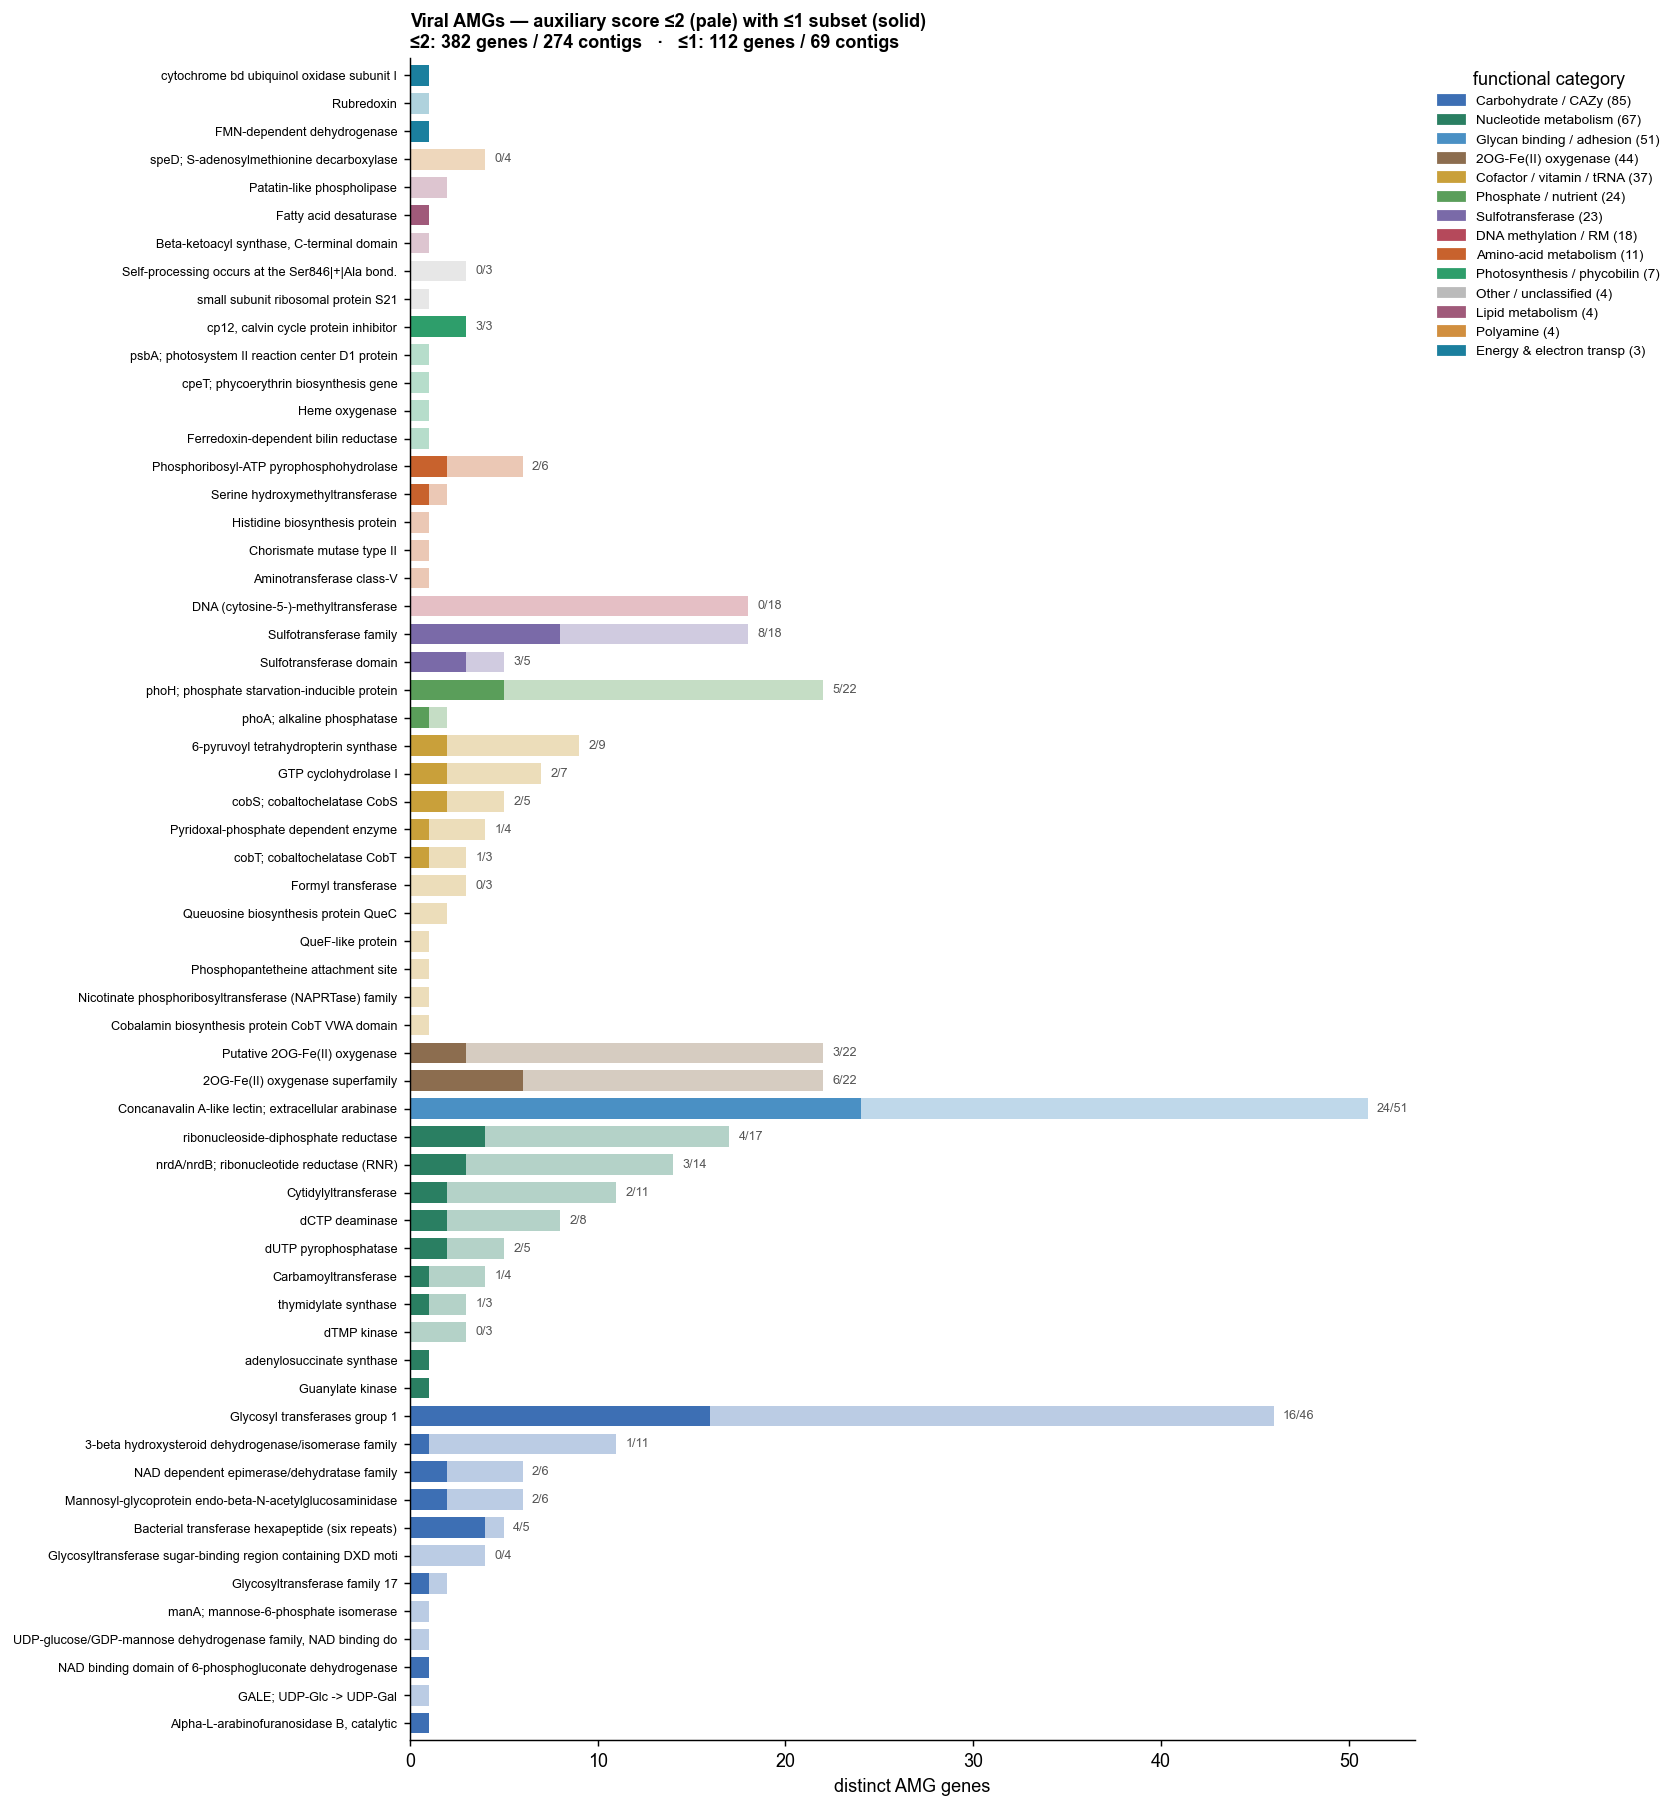

retained at ≤1: 112/382 (29%)

products lost entirely at ≤1:
                                                    gene_product                    function  n2
                                        GALE; UDP-Glc -> UDP-Gal         Carbohydrate / CAZy   1
UDP-glucose/GDP-mannose dehydrogenase family, NAD binding domain         Carbohydrate / CAZy   1
                             manA; mannose-6-phosphate isomerase         Carbohydrate / CAZy   1
   Glycosyltransferase sugar-binding region containing DXD motif         Carbohydrate / CAZy   4
                                                     dTMP kinase       Nucleotide metabolism   3
                  Cobalamin biosynthesis protein CobT VWA domain   Cofactor / vitamin / tRNA   1
          Nicotinate phosphoribosyltransferase (NAPRTase) family   Cofactor / vitamin / tRNA   1
                              Phosphopantetheine attachment site   Cofactor / vitamin / tRNA   1
                                               QueF-like protein  

In [30]:
# pale bar = <=2, solid = the <=1 subset of it
m = (inv.merge(inv1[["gene_product","n_genes"]].rename(columns={"n_genes":"n1"}),
               on="gene_product", how="left")
        .rename(columns={"n_genes":"n2"}))
m["n1"] = m["n1"].fillna(0).astype(int)

order = [c for c in func_counts.index if c in set(m.function)]
m["__c"] = m.function.map({c:i for i,c in enumerate(order)})
m = m.sort_values(["__c","n2"], ascending=[True,True])

fig, ax = plt.subplots(figsize=(13, max(5, 0.28*len(m))))
y = np.arange(len(m))
cols = [PALETTE.get(f,"#999") for f in m.function]
ax.barh(y, m.n2, color=cols, alpha=0.35, height=0.74)
ax.barh(y, m.n1, color=cols, height=0.74)
ax.set_yticks(y); ax.set_yticklabels(m["gene_product"].str.slice(0,60), fontsize=7)
for i, (a, b) in enumerate(zip(m.n2, m.n1)):
    if a >= 3:                                  # only label bars big enough to read
        ax.text(a+0.5, i, f"{b}/{a}", va="center", fontsize=7, color="#555")
ax.set_xlabel("distinct AMG genes")
ax.set_title("Viral AMGs \u2014 auxiliary score \u22642 (pale) with \u22641 subset (solid)\n"
             f"\u22642: {len(survivors_genes)} genes / {survivors_genes['scaffold'].nunique()} contigs"
             f"   \u00b7   \u22641: {len(one)} genes / {one['scaffold'].nunique()} contigs",
             loc="left", fontweight="bold", fontsize=10)
handles = [plt.Rectangle((0,0),1,1,color=PALETTE.get(c,"#999")) for c in order]
ax.legend(handles, [f"{c} ({int(func_counts[c])})" for c in order],
          loc="upper left", bbox_to_anchor=(1.01,1), frameon=False,
          fontsize=7.5, title="functional category")
ax.margins(y=0.004)
fig.subplots_adjust(right=0.72)
save(fig, "figE2_amg_inventory_both_cutoffs"); plt.show()

print(f"retained at \u22641: {m.n1.sum()}/{m.n2.sum()} ({100*m.n1.sum()/m.n2.sum():.0f}%)")
print("\nproducts lost entirely at \u22641:")
print(m.loc[m.n1==0, ["gene_product","function","n2"]].to_string(index=False))

In [31]:
#transporters
TRANSPORT_KW = ["transporter","transport system","permease","channel","antiport","symport","efflux",
                "pump","aquaporin","mechanosensitive","abc-","abc transport","uptake"]
ION_SALT_KW  = ["na+","sodium","k+","potassium","trk","kdp","kef","nha","mnh","cation","chloride",
                "mechanosensitive","msc","osmo","betaine","choline","proline","glycine betaine",
                "ectoine","compatible solute","magnesium","cora"]

def _has(t, kws): return any(k in str(t).lower() for k in kws)

trans = survivors_genes[survivors_genes["gene_description"].apply(lambda d: _has(d, TRANSPORT_KW))].copy()
print(f"{len(trans)} transporter AMGs of {len(survivors_genes)}")
if len(trans):
    trans["salinity_candidate"] = trans.gene_description.apply(lambda d: _has(d, ION_SALT_KW))
    print(trans[["gene_id","auxiliary_score","amg_flags","gene_description","salinity_candidate"]]
            .to_string(index=False, max_colwidth=58))

0 transporter AMGs of 382


In [32]:
#dram-v annotatoins
sh = survivors_genes.copy()
for c in ["sheet","header","subheader","module"]:
    sh[c] = sh[c].replace("", np.nan)

for c in ["sheet","header","subheader","module"]:
    n = sh[c].notna().sum()
    print(f"{c:10s} {n:4d}/{len(sh)}  ({100*n/len(sh):.0f}%)")

print()
print(sh.groupby([sh.sheet.fillna("-"), sh.header.fillna("-"), sh.subheader.fillna("-")])
        .size().to_string())

print("\nkeyword category vs DRAM sheet:")
ct = pd.crosstab(sh["function"], sh["sheet"].fillna("unassigned"))
print(ct.to_string())
ct.to_csv(FIG_DIR/"amg_keyword_vs_sheet_crosstab.csv")

sheet        70/382  (18%)
header       70/382  (18%)
subheader    38/382  (10%)
module       90/382  (24%)

sheet             header                         subheader 
-                 -                              -             312
Energy            Oxygen                         -               1
                  Photosynthesis                 -               1
MISC              Information systems            -               1
                                                 Nucleotide     38
                  aerobic corrin ring synthesis  -               8
Organic Nitrogen  Amino Acid                     -              18
                  Peptidase                      -               3

keyword category vs DRAM sheet:
sheet                        Energy  MISC  Organic Nitrogen  unassigned
function                                                               
2OG-Fe(II) oxygenase              0     0                 0          44
Amino-acid metabolism             0     0     

In [33]:
sub = amg[amg.pass_cutoff]
print(f"{len(sub)} rows | {sub.gene.nunique()} genes | {sub.scaffold.nunique()} contigs")

multi = sub.groupby("gene").size()
print(f"genes with >1 row: {(multi>1).sum()} (max {multi.max()})")
if (multi>1).any():
    mg = sub[sub.gene.isin(multi[multi>1].index)]
    print(f"rows disagreeing on sheet: {(mg.groupby('gene').sheet.nunique()>1).sum()}")

per_contig = sub.drop_duplicates("gene").groupby("scaffold").size()
print(f"\ncontigs with >1 AMG: {(per_contig>1).sum()} (max {per_contig.max()})")
print(per_contig.value_counts().sort_index().to_string())

502 rows | 382 genes | 274 contigs
genes with >1 row: 64 (max 6)
rows disagreeing on sheet: 23

contigs with >1 AMG: 64 (max 9)
1    210
2     46
3      7
4      5
5      2
6      2
8      1
9      1


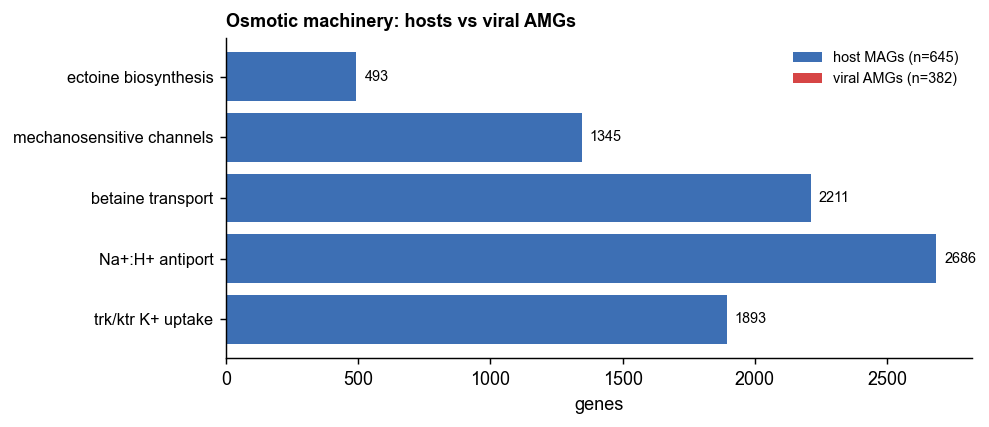

viral ion/osmolyte transport AMGs: 0


In [34]:
#aquired host dram annotations and plugged in numbers here
HOST_OSMOTIC = {"trk/ktr K+ uptake": 1893, "Na+:H+ antiport": 2686, "betaine transport": 2211,
                "mechanosensitive channels": 1345, "ectoine biosynthesis": 493}
viral_ion = int(survivors_genes["gene_description"].str.lower().str.contains(IONTRANS_RX).sum())

fig, ax = plt.subplots(figsize=(7.4, 3.2))
ks = list(HOST_OSMOTIC); vs = [HOST_OSMOTIC[k] for k in ks]; y = np.arange(len(ks))
ax.barh(y, vs, color="#3d6fb4", label="host MAGs (n=645)")
ax.barh(y, [viral_ion]*len(ks), color="#d64545", label=f"viral AMGs (n={len(survivors_genes)})")
ax.set_yticks(y); ax.set_yticklabels(ks, fontsize=9)
for i, v in enumerate(vs): ax.text(v+30, i, str(v), va="center", fontsize=8)
ax.set_xlabel("genes"); ax.legend(frameon=False, fontsize=8)
ax.set_title("Osmotic machinery: hosts vs viral AMGs", loc="left", fontweight="bold", fontsize=10)
save(fig, "figF_host_vs_viral_osmotic"); plt.show()
print(f"viral ion/osmolyte transport AMGs: {viral_ion}")

In [35]:
# host predictions for AMG-carrying contigs 
IPHOP = Path("/Users/skoog/Desktop/Host_prediction_to_genus_m90.csv")

iphop = pd.read_csv(IPHOP)
print("columns:", list(iphop.columns))

VCOL = next(c for c in iphop.columns if c.strip().lower() == "virus")
TCOL = next(c for c in iphop.columns                      
            if iphop[c].astype(str).str.contains(r"d__", na=False).any())
CCOL = next((c for c in iphop.columns if "confidence" in c.lower()), None)
print(f"using virus={VCOL!r} lineage={TCOL!r} confidence={CCOL!r}")

def rank(tax, r):
    for part in str(tax).split(";"):
        if part.startswith(f"{r}__"):
            v = part[3:].strip()
            return v if v else np.nan
    return np.nan

for r, name in [("d","host_domain"),("p","host_phylum"),("c","host_class"),
                ("f","host_family"),("g","host_genus")]:
    iphop[name] = iphop[TCOL].apply(lambda t: rank(t, r))

hp = iphop[[VCOL,"host_domain","host_phylum","host_class","host_family","host_genus"]
           + ([CCOL] if CCOL else [])].drop_duplicates(VCOL)

survivors_genes["virus_base"] = survivors_genes["scaffold"].str.replace(r"-cat_\d+$", "", regex=True)
j = survivors_genes.merge(hp, left_on="virus_base", right_on=VCOL, how="left")

n_pred, n_tot = j.loc[j.host_domain.notna(),"scaffold"].nunique(), survivors_genes.scaffold.nunique()
print(f"\nAMG contigs with a host prediction: {n_pred}/{n_tot} ({100*n_pred/n_tot:.1f}%)")

ctg = j.drop_duplicates("scaffold")
print("\ndomain (contigs):"); print(ctg.host_domain.value_counts(dropna=False).to_string())
print("\nphylum (contigs):"); print(ctg.host_phylum.value_counts(dropna=False).head(15).to_string())
print("\ngenus (contigs):");  print(ctg.host_genus.value_counts(dropna=False).head(15).to_string())

print("\nAMG category x host domain (genes):")
print(pd.crosstab(j.function, j.host_domain.fillna("no prediction")).to_string())

j.to_csv(FIG_DIR/"amg_contigs_with_host_predictions.tsv", sep="\t", index=False)
print(f"\n-> {'enough for a figure panel' if n_pred >= 50 else 'supplementary table only'} (n={n_pred})")

columns: ['Virus', 'AAI to closest RaFAH reference', 'Host genus', 'Confidence score', 'List of methods']
using virus='Virus' lineage='Host genus' confidence='Confidence score'

AMG contigs with a host prediction: 19/274 (6.9%)

domain (contigs):
host_domain
NaN         255
Bacteria     19

phylum (contigs):
host_phylum
NaN               255
Pseudomonadota     12
Actinomycetota      3
Bacteroidota        2
Bacillota_F         1
Bacillota_A         1

genus (contigs):
host_genus
NaN                 255
Paracoccus            1
Pelagibacter          1
Acinetobacter         1
Rhodococcus           1
UBA9145               1
Amylibacter           1
Bacteroides           1
Lacrimispora          1
Aeromicrobium         1
Hyphobacterium        1
Thalassobacter        1
Bifidobacterium       1
Puniceibacterium      1
Hoeflea               1

AMG category x host domain (genes):
host_domain                  Bacteria  no prediction
function                                            
2OG-Fe(II) oxy

In [36]:
n_iphop = iphop[VCOL].nunique()
print(f"viruses with a host prediction in {IPHOP.name}: {n_iphop:,}")

all_viral = amg["scaffold"].str.replace(r"-cat_\d+$", "", regex=True).nunique()
print(f"distinct viral contigs in amg_summary: {all_viral:,}")
print(f"  (this is AMG-bearing contigs only — substitute your full viral catalog count "
      f"for the real denominator)")

print("\nprediction breakdown across ALL predicted viruses:")
print(iphop.assign(dom=iphop[TCOL].apply(lambda t: rank(t,"d"))).dom.value_counts(dropna=False).to_string())
if CCOL:
    print(f"\nconfidence: median {iphop[CCOL].median():.1f}, "
          f"range {iphop[CCOL].min():.1f}-{iphop[CCOL].max():.1f}")

print("\nmethods used:")
mcol = next((c for c in iphop.columns if "method" in c.lower()), None)
if mcol:
    print(iphop[mcol].str.split(";").str[0].value_counts().head().to_string())

viruses with a host prediction in Host_prediction_to_genus_m90.csv: 561
distinct viral contigs in amg_summary: 697
  (this is AMG-bearing contigs only — substitute your full viral catalog count for the real denominator)

prediction breakdown across ALL predicted viruses:
dom
Bacteria    593
Archaea      16

confidence: median 91.6, range 90.0-99.7

methods used:
List of methods
iPHoP-RF    324
blast       265
CRISPR       15
RaFAH         5


In [37]:
TOTAL_VIRUSES = 11370

n_pred_all = iphop[VCOL].nunique()
amg_contigs = survivors_genes["scaffold"].str.replace(r"-cat_\d+$","",regex=True).unique()
n_amg = len(amg_contigs)
n_amg_pred = pd.Series(amg_contigs).isin(iphop[VCOL]).sum()

print(f"viral sequences (quality-filtered)      : {TOTAL_VIRUSES:,}")
print(f"  with a host prediction                : {n_pred_all:,} ({100*n_pred_all/TOTAL_VIRUSES:.1f}%)")
print(f"AMG-carrying contigs (score <=2)        : {n_amg:,} ({100*n_amg/TOTAL_VIRUSES:.1f}% of catalog)")
print(f"  with a host prediction                : {n_amg_pred:,} ({100*n_amg_pred/n_amg:.1f}% of AMG contigs)")

hp2 = iphop[iphop[VCOL].isin(amg_contigs)].copy()
for r,n in [("d","dom"),("p","phy"),("g","gen")]:
    hp2[n] = hp2[TCOL].apply(lambda t: rank(t,r))
print("\ndomain:"); print(hp2.drop_duplicates(VCOL).dom.value_counts().to_string())
print("\nphylum:"); print(hp2.drop_duplicates(VCOL).phy.value_counts().head(10).to_string())
print("\ngenus:");  print(hp2.drop_duplicates(VCOL).gen.value_counts().head(10).to_string())

viral sequences (quality-filtered)      : 11,370
  with a host prediction                : 561 (4.9%)
AMG-carrying contigs (score <=2)        : 274 (2.4% of catalog)
  with a host prediction                : 19 (6.9% of AMG contigs)

domain:
dom
Bacteria    19

phylum:
phy
Pseudomonadota    12
Actinomycetota     3
Bacteroidota       2
Bacillota_F        1
Bacillota_A        1

genus:
gen
HXMU1420-2        1
Aeromicrobium     1
Pelagibacter      1
Acinetobacter     1
Rhodococcus       1
UBA9145           1
Amylibacter       1
Bacteroides       1
Lacrimispora      1
Hyphobacterium    1


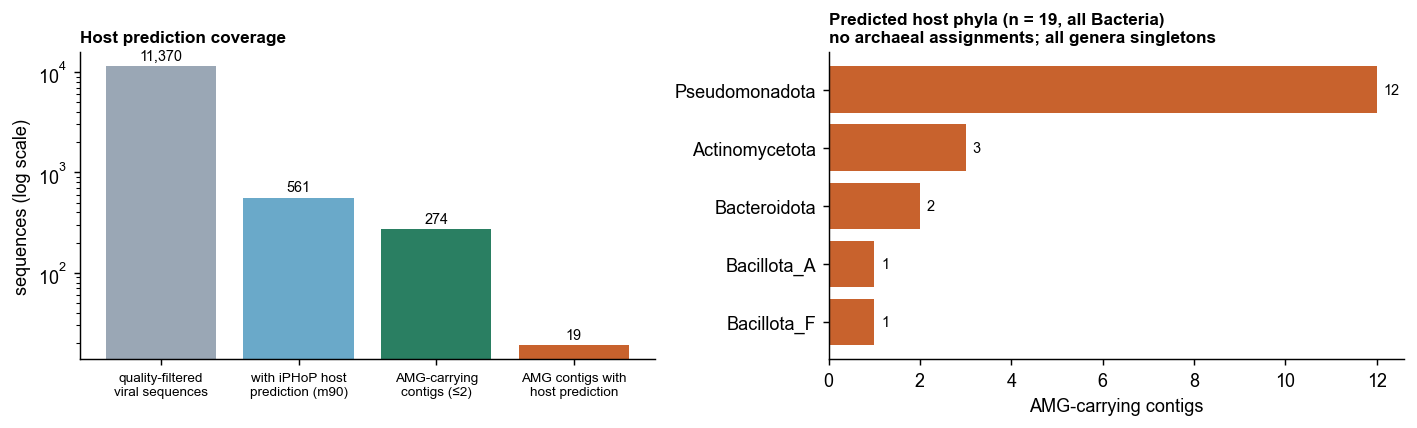

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

steps = ["quality-filtered\nviral sequences", "with iPHoP host\nprediction (m90)",
         "AMG-carrying\ncontigs (\u22642)", "AMG contigs with\nhost prediction"]
vals  = [11370, 561, 274, 19]
b = axes[0].bar(range(4), vals, color=["#9aa7b5","#6aa9c9","#2a7f62","#c8622d"])
axes[0].set_yscale("log"); axes[0].set_xticks(range(4))
axes[0].set_xticklabels(steps, fontsize=7.5)
axes[0].set_ylabel("sequences (log scale)")
for r,v in zip(b, vals):
    axes[0].text(r.get_x()+r.get_width()/2, v*1.15, f"{v:,}", ha="center", fontsize=8)
axes[0].set_title("Host prediction coverage", loc="left", fontweight="bold", fontsize=9.5)

phy = pd.Series({"Pseudomonadota":12,"Actinomycetota":3,"Bacteroidota":2,
                 "Bacillota_F":1,"Bacillota_A":1}).sort_values()
axes[1].barh(phy.index, phy.values, color="#c8622d")
for i,v in enumerate(phy.values):
    axes[1].text(v+0.15, i, str(v), va="center", fontsize=8)
axes[1].set_xlabel("AMG-carrying contigs")
axes[1].set_title("Predicted host phyla (n = 19, all Bacteria)\n"
                  "no archaeal assignments; all genera singletons",
                  loc="left", fontweight="bold", fontsize=9.5)
fig.tight_layout(); save(fig, "figH_host_prediction_coverage"); plt.show()

In [40]:
# AMG abundance across lakes
import re
from scipy import stats
from statsmodels.stats.multitest import multipletests
rng = np.random.default_rng(42)

VIR_RPKM  = Path(AMG_TSV).parent / "coverm_viruses_rpkm_mcf0.75_per_sample.tsv"
WATL_META = Path("/Users/skoog/Desktop/WATL_sample_metadata_merged.xlsx")

ps = pd.read_csv(VIR_RPKM, sep="\t")
ps.rename(columns={ps.columns[0]: "contig_id"}, inplace=True)
ps["contig_id"] = ps["contig_id"].astype(str).str.replace(".faa", "", regex=False)

def _clean(c):
    c = c.replace(" RPKM", "").strip()
    return re.sub(r"(\.sorted)?(\.bam)?$", "", c)
ps.columns = ["contig_id"] + [_clean(c) for c in ps.columns[1:]]

long = ps.melt(id_vars=["contig_id"], var_name="sample", value_name="rpkm")
long["rpkm"] = pd.to_numeric(long["rpkm"], errors="coerce")
long = long[long["rpkm"] > 0]
print(f"{long['contig_id'].nunique():,} contigs x {long['sample'].nunique()} samples")

amg_contigs = set(survivors_genes["scaffold"])
amg_base    = {c.split("-cat_")[0] for c in amg_contigs}
n_direct   = long["contig_id"].isin(amg_contigs).sum()
n_stripped = long["contig_id"].str.replace(r"-cat_\d+$", "", regex=True).isin(amg_base).sum()
print(f"\nrows matching AMG contigs -- direct: {n_direct:,} | stripped: {n_stripped:,}")
print("  RPKM ids :", list(long.contig_id.unique()[:2]))
print("  AMG ids  :", list(amg_contigs)[:2])

if n_direct >= n_stripped:
    long["is_amg"] = long["contig_id"].isin(amg_contigs)
else:
    print("  -> using stripped -cat_N matching")
    long["is_amg"] = long["contig_id"].str.replace(r"-cat_\d+$", "", regex=True).isin(amg_base)

try:
    meta = pd.read_excel(WATL_META, sheet_name="WATL_metadata")
except (ValueError, FileNotFoundError):
    meta = pd.read_excel(WATL_META)
meta = meta.rename(columns={"Sample_ID": "sample"})

d = long.merge(meta[["sample","Lake_name","pH","Salinity","Season"]], on="sample", how="left")
missing = sorted(d.loc[d.pH.isna(), "sample"].dropna().unique())[:10]
print(f"\nrows without metadata: {d.pH.isna().sum():,}" + (f" | unmatched samples: {missing}" if missing else ""))
d = d.dropna(subset=["pH", "Lake_name"])

g = d.groupby("Lake_name")
per_lake = pd.DataFrame({
    "amg_frac_rpkm": d[d.is_amg].groupby("Lake_name")["rpkm"].sum() / g["rpkm"].sum(),
    "amg_frac_rich": g["is_amg"].mean(),
    "pH":            g["pH"].median(),
    "salinity":      g["Salinity"].median(),
    "n_samples":     g["sample"].nunique(),
    "n_contigs":     g["contig_id"].nunique(),
}).reset_index()
per_lake["amg_frac_rpkm"] = per_lake["amg_frac_rpkm"].fillna(0.0)

print(f"\n{len(per_lake)} lakes")
print(per_lake.round(4).to_string(index=False))

def spearman_boot(x, y, n=2000):
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = ~(np.isnan(x) | np.isnan(y)); x, y = x[ok], y[ok]
    rho, p = stats.spearmanr(x, y); idx = np.arange(len(x))
    bs = [stats.spearmanr(x[s], y[s])[0] for s in
          (rng.choice(idx, len(idx), replace=True) for _ in range(n))]
    return rho, p, np.nanpercentile(bs, 2.5), np.nanpercentile(bs, 97.5), len(x)

rows = []
for var in ["pH", "salinity"]:
    for metric in ["amg_frac_rpkm", "amg_frac_rich"]:
        rho, p, lo, hi, n = spearman_boot(per_lake[var], per_lake[metric])
        rows.append(dict(env=var, metric=metric, rho=rho, p=p, lo95=lo, hi95=hi, n_lakes=n))
res = pd.DataFrame(rows)
res["q"] = multipletests(res["p"], method="fdr_bh")[1]
print("\n" + res.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

res.to_csv(FIG_DIR/"amg_abundance_vs_environment.csv", index=False)
per_lake.to_csv(FIG_DIR/"amg_abundance_per_lake.csv", index=False)

9,610 contigs x 66 samples

rows matching AMG contigs -- direct: 0 | stripped: 366
  RPKM ids : ['WATLvirus_00000031', 'WATLvirus_00000043']
  AMG ids  : ['WATLvirus_00324427-cat_1', 'WATLvirus_00309288-cat_1']
  -> using stripped -cat_N matching

rows without metadata: 69 | unmatched samples: ['220806_BK_F6D_DNA_brine']

41 lakes
                           Lake_name  amg_frac_rpkm  amg_frac_rich    pH  salinity  n_samples  n_contigs
                       Anderson Lake         0.0088         0.0208 7.580     145.0          1         96
                        Balicup Lake         0.0210         0.0272 7.840     110.0          1        845
              Bullfinch complex East         0.0061         0.0076 3.650      83.0          1        264
              Bullfinch complex West         0.0000         0.0000 4.400      15.0          1         20
                          Camel Lake         0.0226         0.0228 7.850      85.0          1        963
                       Coramup Creek 

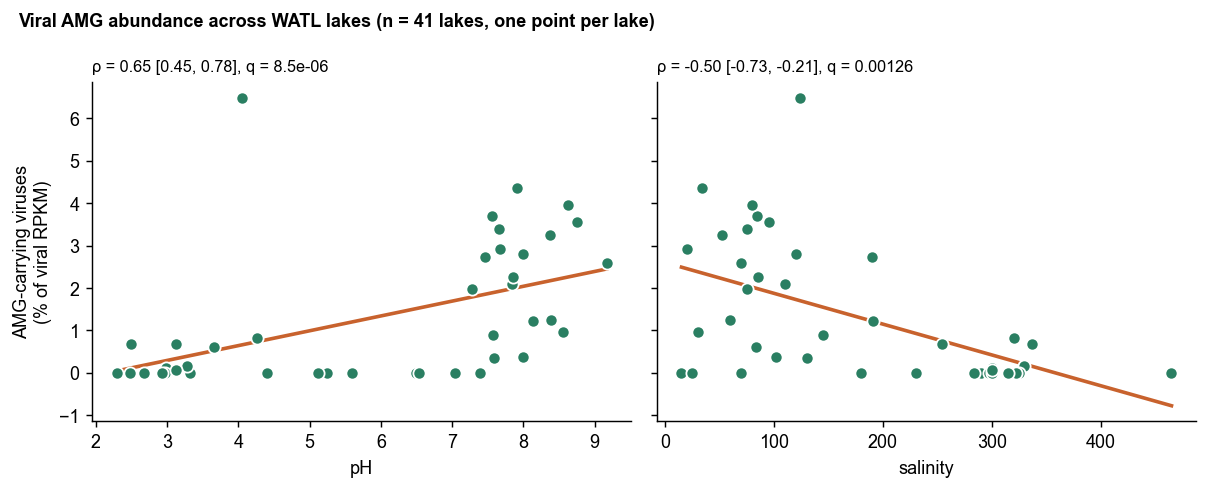

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.8), sharey=True)
for ax, var in zip(axes, ["pH", "salinity"]):
    r = res[(res.env == var) & (res.metric == "amg_frac_rpkm")].iloc[0]
    ax.scatter(per_lake[var], 100*per_lake["amg_frac_rpkm"], s=46,
               c="#2a7f62", edgecolor="white", zorder=3)
    if r["q"] < 0.05:
        z  = np.polyfit(per_lake[var], 100*per_lake["amg_frac_rpkm"], 1)
        xs = np.linspace(per_lake[var].min(), per_lake[var].max(), 50)
        ax.plot(xs, np.polyval(z, xs), color="#c8622d", lw=2, zorder=2)
    ax.set_title(f"\u03c1 = {r['rho']:.2f} [{r['lo95']:.2f}, {r['hi95']:.2f}], "
                 f"q = {r['q']:.3g}{'' if r['q'] < 0.05 else ' (n.s.)'}",
                 loc="left", fontsize=9)
    ax.set_xlabel(var)
axes[0].set_ylabel("AMG-carrying viruses\n(% of viral RPKM)")
fig.suptitle(f"Viral AMG abundance across WATL lakes "
             f"(n = {len(per_lake)} lakes, one point per lake)",
             x=0.02, ha="left", fontweight="bold", fontsize=10)
fig.tight_layout(); save(fig, "figI_amg_abundance_vs_env"); plt.show()

In [42]:
import statsmodels.formula.api as smf

print(f"pH vs salinity: rho={stats.spearmanr(per_lake.pH, per_lake.salinity)[0]:.3f}")
print(f"n_contigs vs AMG fraction: rho={stats.spearmanr(per_lake.n_contigs, per_lake.amg_frac_rpkm)[0]:.3f}")

z = per_lake.copy()
for c in ["amg_frac_rpkm","pH","salinity","n_contigs"]:
    z[c+"_r"] = z[c].rank()

m1 = smf.ols("amg_frac_rpkm_r ~ pH_r + salinity_r", data=z).fit()
m2 = smf.ols("amg_frac_rpkm_r ~ pH_r + salinity_r + n_contigs_r", data=z).fit()
print("\npH + salinity:");            print(m1.summary2().tables[1].round(4).to_string())
print("\n+ detection covariate:");    print(m2.summary2().tables[1].round(4).to_string())

MIN_CONTIGS = 100
sub = per_lake[per_lake.n_contigs >= MIN_CONTIGS]
print(f"\n--- lakes with >= {MIN_CONTIGS} contigs: n = {len(sub)} ---")
for var in ["pH","salinity"]:
    rho,p,lo,hi,n = spearman_boot(sub[var], sub["amg_frac_rpkm"])
    print(f"  {var:9s} rho={rho:+.3f} p={p:.4f} CI[{lo:+.2f},{hi:+.2f}] n={n}")

pH vs salinity: rho=-0.702
n_contigs vs AMG fraction: rho=0.829

pH + salinity:
              Coef.  Std.Err.       t   P>|t|  [0.025   0.975]
Intercept   10.4260    6.7133  1.5530  0.1287 -3.1644  24.0164
pH_r         0.5819    0.1693  3.4380  0.0014  0.2393   0.9245
salinity_r  -0.0784    0.1693 -0.4629  0.6461 -0.4212   0.2644

+ detection covariate:
              Coef.  Std.Err.       t   P>|t|  [0.025   0.975]
Intercept    4.9641    4.7175  1.0523  0.2995 -4.5944  14.5226
pH_r         0.1821    0.1322  1.3776  0.1766 -0.0857   0.4498
salinity_r  -0.0885    0.1171 -0.7560  0.4544 -0.3258   0.1488
n_contigs_r  0.6701    0.1028  6.5165  0.0000  0.4617   0.8785

--- lakes with >= 100 contigs: n = 25 ---
  pH        rho=+0.523 p=0.0073 CI[+0.13,+0.78] n=25
  salinity  rho=-0.362 p=0.0756 CI[-0.71,+0.09] n=25


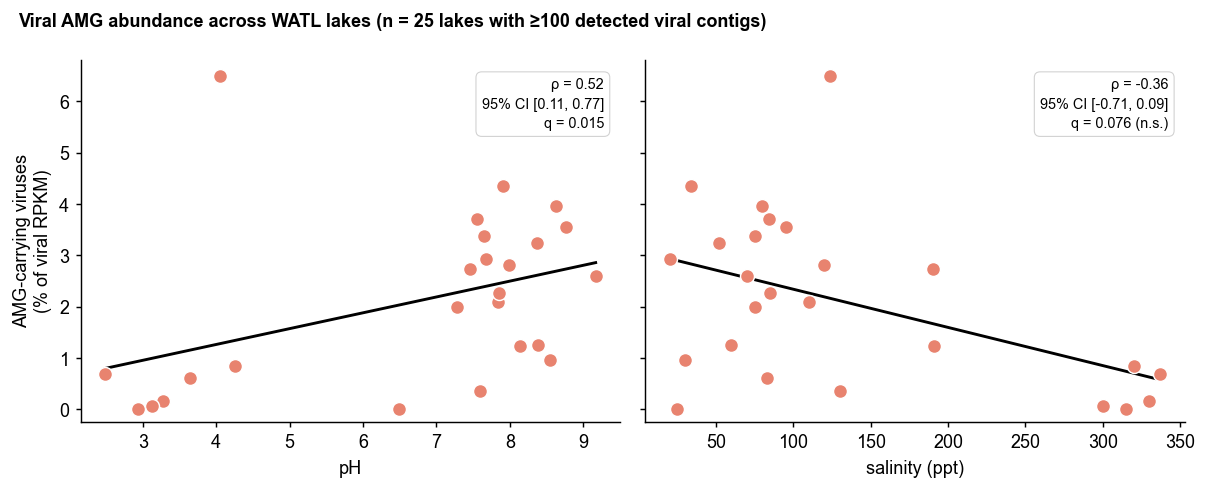

pH        rho=+0.523 p=0.0073 q=0.0146 CI[+0.11,+0.77] n=25
salinity  rho=-0.362 p=0.0756 q=0.0756 CI[-0.71,+0.09] n=25


In [49]:
from statsmodels.stats.multitest import multipletests

MIN_CONTIGS = 100
sub = per_lake[per_lake.n_contigs >= MIN_CONTIGS]

stats_rows = {v: spearman_boot(sub[v], sub["amg_frac_rpkm"]) for v in ["pH", "salinity"]}
qvals = dict(zip(stats_rows, multipletests([s[1] for s in stats_rows.values()],
                                           method="fdr_bh")[1]))

SALMON = "#E8836F"
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.8), sharey=True)

for ax, var in zip(axes, ["pH", "salinity"]):
    rho, p, lo, hi, n = stats_rows[var]
    q = qvals[var]

    ax.scatter(sub[var], 100*sub["amg_frac_rpkm"], s=60, c=SALMON,
               edgecolor="white", linewidth=0.8, zorder=3)

    z  = np.polyfit(sub[var], 100*sub["amg_frac_rpkm"], 1)
    xs = np.linspace(sub[var].min(), sub[var].max(), 50)
    if q < 0.05:
        ax.plot(xs, np.polyval(z, xs), color="black", lw=1.6, zorder=2)
    else:
        ax.plot(xs, np.polyval(z, xs), color="black", lw=1.6, zorder=2)

    ax.text(0.97, 0.95,
            f"\u03c1 = {rho:.2f}\n95% CI [{lo:.2f}, {hi:.2f}]\nq = {q:.3f}"
            f"{'' if q < 0.05 else ' (n.s.)'}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            linespacing=1.5,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="#cccccc", linewidth=0.6, alpha=0.9))

    ax.set_xlabel("pH" if var == "pH" else "salinity (ppt)")
    ax.tick_params(length=3)

axes[0].set_ylim(bottom=-0.25)
axes[0].set_ylabel("AMG-carrying viruses\n(% of viral RPKM)")
fig.suptitle(f"Viral AMG abundance across WATL lakes "
             f"(n = {len(sub)} lakes with \u2265{MIN_CONTIGS} detected viral contigs)",
             x=0.02, ha="left", fontweight="bold", fontsize=10)
fig.tight_layout()
save(fig, "figI_amg_abundance_vs_env"); plt.show()

for v, (rho, p, lo, hi, n) in stats_rows.items():
    print(f"{v:9s} rho={rho:+.3f} p={p:.4f} q={qvals[v]:.4f} CI[{lo:+.2f},{hi:+.2f}] n={n}")